In [1]:
import os
for v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'
# then numpy / xso / ssh imports BELOW this line

In [2]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

In [ ]:
import seasonal_scan_harness as ssh

# loosened floor (surfaced): a -0.001 graze won't discard an otherwise-fine combo;
# genuine runaways still terminate -> has_nan. Workers auto-pin BLAS (reproducible).
SK = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': -1e-2}

res = ssh.run_seasonal_scan(
    constructs = ['maranon_ward'],                 # drill our best construct only
    groups     = ['pre+recovery', 'post'],         # the two joint-objective eras
    fish_rates = [0.0, 0.1, 0.2, 0.3, 0.4],        # graded axis (joint pairs pre>=post post-hoc)
    param_grid = {
        'GGE':       [0.25, 0.31, 0.33],           # #2 large-Z   (Stock / Taniguchi / Hansen)
        'mP':        [0.0015, 0.01, 0.02],         # #1/#3 PP+Micro (Taniguchi / mid / Ward; >0.02 collapses)
        'm_Z':       [0.05, 0.10, 0.20],           # #2 large-Z   (low end destabilises -> has_nan filters)
        'KsZ':       [0.15, 0.23, 0.45],           # #1 PP        (Ward / Dutk2020 / Dutk2015a; Type III window)
        'sigma_log': [0.15, 0.20, 0.25],           # #2/#3 kernel width (Mattern / mid / Banas)
    },
    years=60, spinup=15,
    solver_kwargs=SK,
    save_path='seasonal_scan_drill.pkl',
    processes=None,                                # = cpu-1
)
print(res.table().round(3).to_string(index=False))

[seasonal scan] 2430 runs: ['maranon_ward'] x ['pre+recovery', 'post'] x fish=[0.0, 0.1, 0.2, 0.3, 0.4] x params['GGE', 'mP', 'm_Z', 'KsZ', 'sigma_log'] | 60 yr each (spin-up 15)
solver: {'method': 'RK45', 'atol': 1e-06, 'rtol': 0.0001, 'instability_neg_threshold': -0.01} | spline_s=0.0 | processes=cpu-1
--- run_parallel_tasks: 2430 tasks, 19 workers (seasonal) ---
    1/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.0015, 'm_Z': 0.05, 'KsZ': 0.45, 'sigma_log': 0.2} mcs= 4.78/ 4.36 micro=0.32 Z200pk=0.159 conv=1.00 nan=False score= 0.23 |  0.3m ETA 614.2m
    2/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.45, 'sigma_log': 0.2} mcs= 6.04/ 5.47 micro=0.37 Z200pk=0.122 conv=0.99 nan=False score= 0.18 |  0.3m ETA 320.7m
    3/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.45, 'sigma_log': 0.25} mcs= 5.29/ 4.09 micro=0.33 Z200pk=0.170 conv=0.98 nan=False score= 0.20 |  0.3m ETA 217.

/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2800 on Z[9] = -0.0337. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   20/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.01, 'm_Z': 0.1, 'KsZ': 0.15, 'sigma_log': 0.15} mcs=  nan/  nan micro= nan Z200pk=  nan conv= nan nan=True score=  nan |  0.4m ETA 52.3m
   21/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.0015, 'm_Z': 0.2, 'KsZ': 0.23, 'sigma_log': 0.15} mcs= 6.28/ 6.14 micro=0.37 Z200pk=0.130 conv=0.92 nan=False score= 0.25 |  0.5m ETA 57.1m
   22/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.0015, 'm_Z': 0.2, 'KsZ': 0.45, 'sigma_log': 0.2} mcs= 7.76/ 7.33 micro=0.43 Z200pk=0.087 conv=0.99 nan=False score= 0.39 |  0.5m ETA 54.9m
   23/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.0015, 'm_Z': 0.2, 'KsZ': 0.45, 'sigma_log': 0.25} mcs= 7.05/ 6.63 micro=0.42 Z200pk=0.112 conv=0.96 nan=False score= 0.34 |  0.5m ETA 53.1m
   24/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.0015, 'm_Z': 0.2, 'KsZ': 0.23, 'sigma_log': 0.2} mcs= 4.91/ 4.65 micro=0.31 Z200pk=0.129 

/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3078 on P[16] = -0.0131. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


   27/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.0015, 'm_Z': 0.2, 'KsZ': 0.15, 'sigma_log': 0.2} mcs= 3.29/ 3.21 micro=0.21 Z200pk=0.115 conv=1.00 nan=False score= 0.42 |  0.5m ETA 48.8m
   28/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.01, 'm_Z': 0.05, 'KsZ': 0.23, 'sigma_log': 0.15} mcs= 3.30/ 2.55 micro=0.21 Z200pk=0.195 conv=1.02 nan=False score= 0.40 |  0.6m ETA 47.6m
   29/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.01, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2} mcs=  nan/  nan micro= nan Z200pk=  nan conv= nan nan=True score=  nan |  0.6m ETA 46.4m
   30/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.01, 'm_Z': 0.05, 'KsZ': 0.45, 'sigma_log': 0.2} mcs= 3.04/ 2.59 micro=0.20 Z200pk=0.115 conv=0.99 nan=False score= 0.41 |  0.6m ETA 44.8m
   31/2430 maranon_ward  pre+recovery  fish=0    {'GGE': 0.25, 'mP': 0.01, 'm_Z': 0.05, 'KsZ': 0.45, 'sigma_log': 0.15} mcs= 3.42/ 3.12 micro=0.23 Z200pk=0.118 conv

...

  1195/2430 maranon_ward  pre+recovery  fish=0.4  {'GGE': 0.33, 'mP': 0.02, 'm_Z': 0.05, 'KsZ': 0.45, 'sigma_log': 0.2} mcs= 3.34/ 2.34 micro=0.18 Z200pk=0.095 conv=1.01 nan=False score= 0.42 | 15.7m ETA 16.3m
  1196/2430 maranon_ward  pre+recovery  fish=0.4  {'GGE': 0.33, 'mP': 0.02, 'm_Z': 0.05, 'KsZ': 0.45, 'sigma_log': 0.15} mcs= 3.20/ 2.44 micro=0.18 Z200pk=0.054 conv=0.99 nan=False score= 0.44 | 15.7m ETA 16.2m
  1197/2430 maranon_ward  pre+recovery  fish=0.4  {'GGE': 0.33, 'mP': 0.02, 'm_Z': 0.2, 'KsZ': 0.15, 'sigma_log': 0.2} mcs=  nan/  nan micro= nan Z200pk=  nan conv= nan nan=True score=  nan | 15.7m ETA 16.2m


/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2.033e+04 on P[16] = -0.0341. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  1198/2430 maranon_ward  pre+recovery  fish=0.4  {'GGE': 0.33, 'mP': 0.02, 'm_Z': 0.05, 'KsZ': 0.15, 'sigma_log': 0.2} mcs= 3.64/ 3.55 micro=0.24 Z200pk=0.087 conv=1.01 nan=False score= 0.35 | 15.8m ETA 16.2m
  1199/2430 maranon_ward  pre+recovery  fish=0.4  {'GGE': 0.33, 'mP': 0.02, 'm_Z': 0.05, 'KsZ': 0.23, 'sigma_log': 0.2} mcs=  nan/  nan micro= nan Z200pk=  nan conv= nan nan=True score=  nan | 15.8m ETA 16.2m
  1200/2430 maranon_ward  pre+recovery  fish=0.4  {'GGE': 0.33, 'mP': 0.02, 'm_Z': 0.05, 'KsZ': 0.45, 'sigma_log': 0.25} mcs= 3.04/ 2.49 micro=0.21 Z200pk=0.101 conv=0.95 nan=False score= 0.42 | 15.8m ETA 16.2m


/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=4547 on P[27] = -0.0169. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3786 on Z[1] = -0.0264. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  1201/2430 maranon_ward  pre+recovery  fish=0.4  {'GGE': 0.33, 'mP': 0.02, 'm_Z': 0.05, 'KsZ': 0.15, 'sigma_log': 0.25} mcs= 4.69/ 4.74 micro=0.32 Z200pk=0.089 conv=1.00 nan=False score= 0.23 | 15.8m ETA 16.2m
  1202/2430 maranon_ward  pre+recovery  fish=0.4  {'GGE': 0.33, 'mP': 0.02, 'm_Z': 0.2, 'KsZ': 0.15, 'sigma_log': 0.15} mcs=  nan/  nan micro= nan Z200pk=  nan conv= nan nan=True score=  nan | 15.8m ETA 16.1m
  1203/2430 maranon_ward  pre+recovery  fish=0.4  {'GGE': 0.33, 'mP': 0.02, 'm_Z': 0.2, 'KsZ': 0.23, 'sigma_log': 0.25} mcs=  nan/  nan micro= nan Z200pk=  nan conv= nan nan=True score=  nan | 15.8m ETA 16.1m
  1204/2430 maranon_ward  pre+recovery  fish=0.4  {'GGE': 0.33, 'mP': 0.02, 'm_Z': 0.1, 'KsZ': 0.15, 'sigma_log': 0.2} mcs= 3.66/ 3.53 micro=0.24 Z200pk=0.091 conv=1.00 nan=False score= 0.35 | 15.8m ETA 16.1m
  1205/2430 maranon_ward  pre+recovery  fish=0.4  {'GGE': 0.33, 'mP': 0.02, 'm_Z': 0.1, 'KsZ': 0.15, 'sigma_log': 0.25} mcs= 4.74/ 4.74 micro=0.32 Z200pk=0.082 co

In [4]:
import seasonal_scan_harness as ssh, numpy as np, pandas as pd

res = ssh.load_results('seasonal_scan_drill.pkl')
df  = res.df[~res.df.has_nan.astype(bool)].copy()
PARAMS = list(res.param_names)                       # all five: GGE, mP, m_Z, KsZ, sigma_log

def grab(r):                                         # diagnostic metrics for one selected era-run
    return dict(sc=round(r['score'], 3), mcs=round(r['mcs_med'], 2), micro=round(r['micro_med'], 3),
                PP=round(r['PP_med'], 3), Z200=round(r['Z200_med'], 3), Z500=round(r['Z500_med'], 4))

rows = []
for keys, g in df.groupby(['construct'] + PARAMS):
    pre  = g[g.group == 'pre+recovery'].set_index('fish')
    post = g[g.group == 'post'].set_index('fish')
    best = None
    for rp in pre.index:                             # graded constraint: post fish <= pre fish
        for rq in post.index:
            if rq <= rp:
                j = max(pre.loc[rp, 'score'], post.loc[rq, 'score'])
                if best is None or j < best['joint']:
                    pr, po = grab(pre.loc[rp]), grab(post.loc[rq])
                    best = dict(joint=round(j, 3), pre_fish=rp, post_fish=rq,
                                pre_sc=pr['sc'], post_sc=po['sc'],
                                pre_mcs=pr['mcs'], post_mcs=po['mcs'],
                                pre_micro=pr['micro'], post_micro=po['micro'],
                                pre_PP=pr['PP'], post_PP=po['PP'],
                                pre_Z200=pr['Z200'], post_Z200=po['Z200'],
                                pre_Z500=pr['Z500'], post_Z500=po['Z500'])
    if best:
        best.update(dict(zip(['cons'] + PARAMS, keys)))
        rows.append(best)

J = pd.DataFrame(rows)
cols = ['cons'] + PARAMS + ['pre_fish', 'post_fish', 'joint', 'pre_sc', 'post_sc',
        'pre_mcs', 'post_mcs', 'pre_micro', 'post_micro',
        'pre_PP', 'post_PP', 'pre_Z200', 'post_Z200', 'pre_Z500', 'post_Z500']

ng = df.groupby(['construct'] + PARAMS).ngroups
print(f"{len(J)} param-combos with a valid both-era joint (of {ng} with >=1 finite run)")
print("obs median  pre: mcs 4.84 micro 0.27 PP 0.29 Z200 0.047 Z500 0.024 | "
      "post: mcs 2.30 micro 0.13 PP 0.20 Z200 0.055 Z500 0.033")
print(J.sort_values('joint')[cols].head(25).to_string(index=False))

105 param-combos with a valid both-era joint (of 242 with >=1 finite run)
obs median  pre: mcs 4.84 micro 0.27 PP 0.29 Z200 0.047 Z500 0.024 | post: mcs 2.30 micro 0.13 PP 0.20 Z200 0.055 Z500 0.033
        cons  GGE     mP  m_Z  KsZ  sigma_log  pre_fish  post_fish  joint  pre_sc  post_sc  pre_mcs  post_mcs  pre_micro  post_micro  pre_PP  post_PP  pre_Z200  post_Z200  pre_Z500  post_Z500
maranon_ward 0.31 0.0015 0.10 0.23       0.20       0.4        0.0  0.195   0.195    0.181     3.37      2.49      0.248       0.168   0.150    0.102     0.016      0.038    0.0002     0.0043
maranon_ward 0.25 0.0100 0.05 0.23       0.20       0.4        0.0  0.197   0.189    0.197     3.38      2.42      0.249       0.167   0.150    0.105     0.013      0.025    0.0000     0.0016
maranon_ward 0.25 0.0100 0.20 0.15       0.25       0.2        0.0  0.205   0.202    0.205     4.51      2.56      0.319       0.174   0.182    0.129     0.063      0.055    0.0160     0.0240
maranon_ward 0.25 0.0100 0.10 0.2

In [6]:
import seasonal_scan_harness as ssh, numpy as np, pandas as pd

res = ssh.load_results('seasonal_scan_drill.pkl')
PARAMS = list(res.param_names)
MO = np.arange(1, 13)

# obs pre+recovery MCS seasonal cycle (the swing we want to reproduce)
om = ssh.build_obs_monthly(['pre+recovery'])['pre+recovery']
ocyc = om.dropna(subset=['mcs']).groupby('mo')['mcs'].median().reindex(MO).values
print(f"obs pre+rec MCS cycle:  peak {np.nanmax(ocyc):.2f} um (mo {int(np.nanargmax(ocyc)+1)}) | "
      f"trough {np.nanmin(ocyc):.2f} | amplitude {np.nanmax(ocyc)-np.nanmin(ocyc):.2f}")

rows = []
for r in res.records:
    if r.get('group') != 'pre+recovery' or r.get('has_nan'):
        continue
    c = np.asarray(r.get('clim_mcs', np.full(12, np.nan)), float)
    if not np.isfinite(c).any():
        continue
    pk, tr = np.nanmax(c), np.nanmin(c)
    rows.append(dict({p: r.get(p) for p in PARAMS},
                     fish=r.get('fish'), pre_sc=round(r.get('score', np.nan), 3),
                     mcs_med=round(r.get('mcs_med', np.nan), 2),
                     peak=round(pk, 2), trough=round(tr, 2), amp=round(pk - tr, 2),
                     peak_mo=int(np.nanargmax(c) + 1),
                     micro_med=round(r.get('micro_med', np.nan), 3),
                     Z200=round(r.get('Z200_med', np.nan), 3)))
P = pd.DataFrame(rows)

CUT = 0.35   # composition cutoff — loosen if it over-filters the blooming fits
top = P[P.pre_sc <= CUT].sort_values('amp', ascending=False)
print(f"\npre+recovery runs (pre_sc <= {CUT}) ranked by MCS seasonal amplitude (peak - trough):")
print(top.head(25).to_string(index=False))

obs pre+rec MCS cycle:  peak 23.98 um (mo 4) | trough 1.76 | amplitude 22.22

pre+recovery runs (pre_sc <= 0.35) ranked by MCS seasonal amplitude (peak - trough):
 GGE     mP  m_Z  KsZ  sigma_log  fish  pre_sc  mcs_med  peak  trough   amp  peak_mo  micro_med  Z200
0.31 0.0015 0.10 0.23       0.20   0.4   0.195     3.37 32.18    2.71 29.47        4      0.248 0.016
0.33 0.0100 0.20 0.23       0.20   0.2   0.331     2.66 30.61    2.36 28.25        5      0.186 0.035
0.31 0.0100 0.20 0.23       0.20   0.3   0.224     3.28 30.65    2.81 27.84        4      0.230 0.013
0.25 0.0100 0.05 0.23       0.20   0.3   0.313     2.69 29.39    1.99 27.40        4      0.192 0.015
0.25 0.0100 0.10 0.23       0.20   0.4   0.128     3.90 30.25    3.12 27.13        4      0.277 0.011
0.25 0.0100 0.10 0.23       0.20   0.2   0.268     2.95 27.29    2.19 25.10        4      0.216 0.019
0.31 0.0015 0.20 0.23       0.20   0.2   0.231     3.20 27.97    2.88 25.09        4      0.228 0.031
0.25 0.0015 0.05 0.23


{'construct': 'maranon_ward', 'GGE': 0.25, 'mP': 0.01, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.25} | fish=0.4
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           5.33      8.65      4.58      4.84   -0.38   -0.05
pico          0.45     0.436     0.463     0.429   +0.03   +0.08
nano         0.205     0.217     0.203     0.205   -0.06   -0.01
micro        0.345     0.346     0.325     0.271   -0.00   +0.20
sumP         0.491     0.633     0.464     0.535   -0.22   -0.13
N             6.09      1.46      6.44       1.2   +3.18   +4.38
PP           0.174     0.548     0.175     0.286   -0.68   -0.39
Export        2.73      3.51      2.84      2.68   -0.22   +0.06
Z200        0.0533    0.0504    0.0509    0.0472   +0.06   +0.08
Z500        0.0165    0.0287    0.0136    0.0235   -0.43   -0.42
score   mean=0.195  med=0.112  joint(max)=0.195   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=0.97 Z200

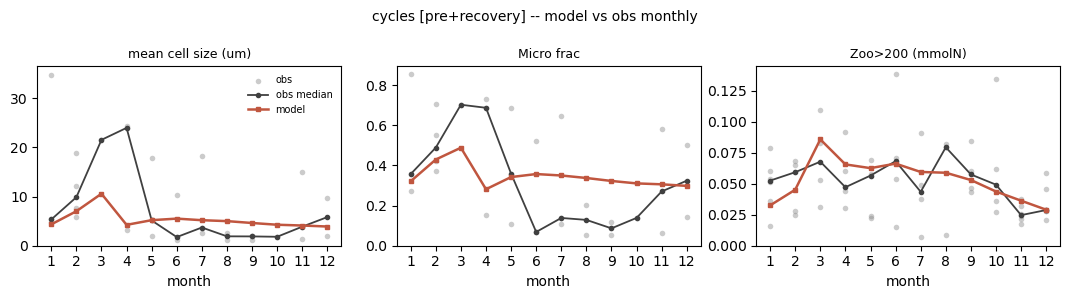

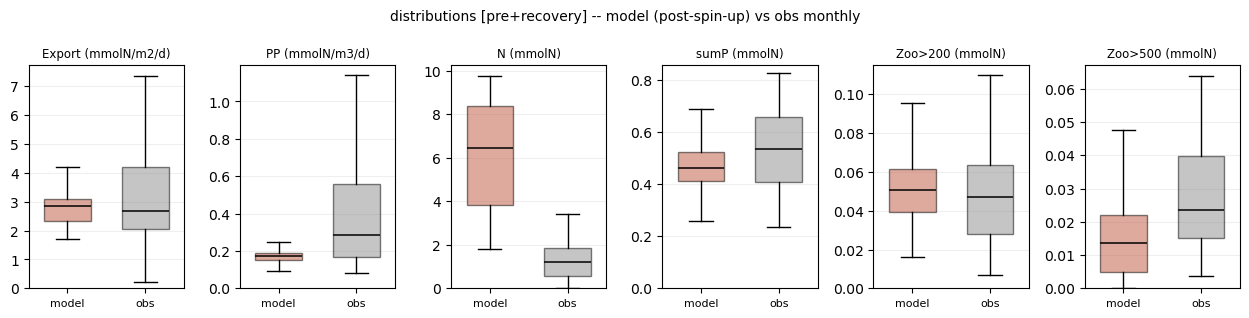

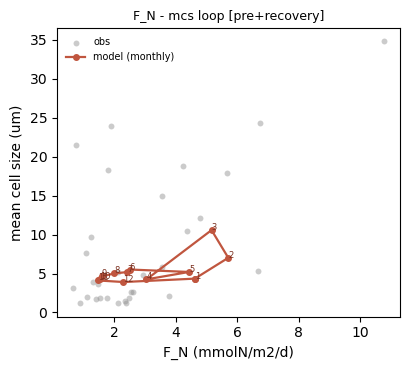


{'construct': 'maranon_ward', 'GGE': 0.25, 'mP': 0.01, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.25} | fish=0.0
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           2.29      4.88      2.01       2.3   -0.53   -0.13
pico         0.599     0.546     0.615     0.564   +0.10   +0.09
nano          0.26     0.258     0.262     0.264   +0.00   -0.01
micro        0.141     0.196     0.121     0.125   -0.28   -0.03
sumP          0.33     0.589     0.326      0.46   -0.44   -0.29
N             2.82      1.34      2.93      1.09   +1.10   +1.69
PP           0.126     0.323     0.132     0.202   -0.61   -0.35
Export        2.34      2.73      2.54      2.24   -0.14   +0.14
Z200        0.0674    0.0652      0.07    0.0549   +0.04   +0.28
Z500        0.0202    0.0357    0.0173    0.0331   -0.43   -0.48
score   mean=0.304  med=0.079  joint(max)=0.304   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=0.99 Z200_peak=0.

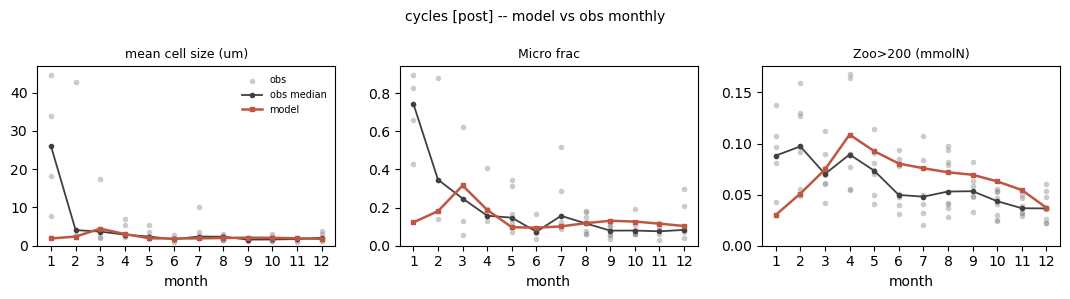

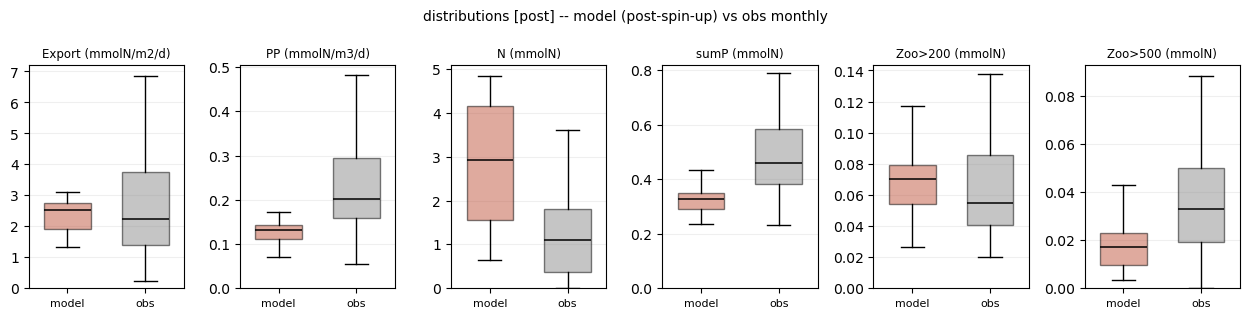

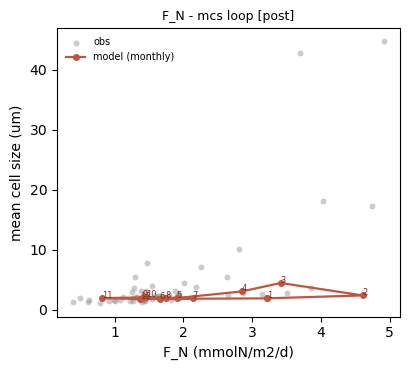

In [10]:
# Row 11 — pronounced bloom + best composition
CAND = dict(construct='maranon_ward', GGE=0.31, mP=0.0015, m_Z=0.20, KsZ=0.23, sigma_log=0.20)
FISH = {'pre+recovery': 0.4, 'post': 0.0}
# alt — Row 17: 
CAND = dict(construct='maranon_ward', GGE=0.25, mP=0.01, m_Z=0.10, KsZ=0.23, sigma_log=0.25)


for g in ('pre+recovery', 'post'):
    clim, r = ssh.run_one(spec, forc[g], fish_rate=FISH[g], years=60, spinup=15,
                          mP=CAND['mP'], m_Z=CAND['m_Z'], grazing=GRZ,
                          iv_overrides=IVO, solver_kwargs=SK, return_traj=True)
    sd.diagnose(clim, r, group=g, spinup=15, obs_targets=obs_t, obs_monthly=obs_m,
                title=f"\n{CAND} | fish={FISH[g]}")

In [3]:
import seasonal_scan_harness as ssh, seasonal_diagnostics as sd, numpy as np

res   = ssh.load_results('seasonal_scan_drill.pkl')
obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'])

# obs reference: the amplitude / duration / peak you're trying to match
MO = np.arange(1, 13)
for g in ('pre+recovery', 'post'):
    c = obs_m[g].dropna(subset=['mcs']).groupby('mo')['mcs'].median().reindex(MO).values
    print(f"obs {g:13s} amp={np.nanmax(c)-np.nanmin(c):5.1f}  dur(>5um)={int(np.nansum(c>5))}  peak={np.nanmax(c):.1f}")

S = sd.survey(res, obs_m)                                   # dur_thresh=5.0 um; adjustable
cols = list(res.param_names) + ['pre_fish', 'post_fish', 'joint', 'pre_sc', 'bloom_rmse',
        'pre_amp', 'post_amp', 'amp_contr', 'pre_dur', 'post_dur', 'dur_contr',
        'pre_mcsmed', 'pre_Z200', 'post_Z200']
top = S[S.joint <= 0.30].sort_values('bloom_rmse')          # fit gate + best cycle match first
print(f"\n{len(S)} (combo, pre_fish) rows; {len(top)} pass joint<=0.30")
print(top[cols].head(25).to_string(index=False))

obs pre+recovery  amp= 22.2  dur(>5um)=6  peak=24.0
obs post          amp= 24.4  dur(>5um)=1  peak=26.0

354 (combo, pre_fish) rows; 28 pass joint<=0.30
 GGE     mP  m_Z  KsZ  sigma_log  pre_fish  post_fish  joint  pre_sc  bloom_rmse  pre_amp  post_amp  amp_contr  pre_dur  post_dur  dur_contr  pre_mcsmed  pre_Z200  post_Z200
0.25 0.0200 0.20 0.23       0.15       0.4        0.0  0.268   0.268       0.210     18.7       1.8       16.9        4         0          4        3.20     0.003      0.010
0.25 0.0015 0.10 0.15       0.20       0.3        0.0  0.228   0.184       0.225     14.9       2.8       12.1        3         0          3        3.41     0.039      0.051
0.25 0.0100 0.05 0.45       0.20       0.4        0.0  0.289   0.289       0.257      8.2       1.3        6.9        3         0          3        3.09     0.001      0.006
0.25 0.0100 0.05 0.23       0.15       0.4        0.0  0.296   0.173       0.259     18.7       1.3       17.4        4         0          4        3.6

In [4]:
import seasonal_scan_harness as ssh, seasonal_diagnostics as sd

SK    = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': -1e-2}
forc  = ssh.build_forcings(['pre+recovery', 'post'])
obs_t = ssh.build_obs_targets(['pre+recovery', 'post'])
obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'])
spec  = ssh.allometry('maranon_ward')

# (tag, params, pre_fish); post_fish = 0.0 throughout (the fit's pick).
# A-C: duration-lens (KsZ 0.15 / sigma 0.25 -- sustained bloom + large-Z). D: amp-lens, for contrast.
CANDS = [
    ('A dur-best',    dict(GGE=0.25, mP=0.0015, m_Z=0.20, KsZ=0.15, sigma_log=0.25), 0.2),
    ('B row3-nbr',    dict(GGE=0.25, mP=0.0100, m_Z=0.20, KsZ=0.15, sigma_log=0.25), 0.2),
    ('C longest-dur', dict(GGE=0.25, mP=0.0015, m_Z=0.10, KsZ=0.15, sigma_log=0.25), 0.2),
    ('D amp-lens',    dict(GGE=0.31, mP=0.0015, m_Z=0.10, KsZ=0.23, sigma_log=0.20), 0.4),
]

def run_cand(P, g, fish):
    return ssh.run_one(spec, forc[g], fish_rate=fish, years=60, spinup=15,
                       mP=P['mP'], m_Z=P['m_Z'],
                       grazing={'KsZ': P['KsZ'], 'sigma_log': P['sigma_log']},
                       iv_overrides={'GrazingRouter': {'gge': P['GGE']}},
                       solver_kwargs=SK, return_traj=True)

# --- Part 1: compare all variants (text only: table + flags + floor margin) ---
for tag, P, pf in CANDS:
    print(f"\n##### {tag}: {P} | pre_fish={pf} / post_fish=0.0 #####")
    for g, fish in (('pre+recovery', pf), ('post', 0.0)):
        clim, r = run_cand(P, g, fish)
        sd.diagnostic_print(clim, g, obs_t, obs_m)


##### A dur-best: {'GGE': 0.25, 'mP': 0.0015, 'm_Z': 0.2, 'KsZ': 0.15, 'sigma_log': 0.25} | pre_fish=0.2 / post_fish=0.0 #####
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           6.75      8.65      4.84      4.84   -0.22   +0.00
pico         0.434     0.436     0.454     0.429   -0.00   +0.06
nano         0.201     0.217     0.189     0.205   -0.07   -0.08
micro        0.364     0.346     0.342     0.271   +0.05   +0.26
sumP         0.574     0.633      0.48     0.535   -0.09   -0.10
N              4.9      1.46      5.16       1.2   +2.36   +3.31
PP           0.174     0.548     0.163     0.286   -0.68   -0.43
Export        2.74      3.51      2.61      2.68   -0.22   -0.02
Z200        0.0621    0.0504    0.0521    0.0472   +0.23   +0.10
Z500        0.0194    0.0287   0.00786    0.0235   -0.32   -0.67
score   mean=0.119  med=0.140  joint(max)=0.140   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 m


=== D amp-lens | {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2} | fish=0.4 ===
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           6.79      8.65      3.41      4.84   -0.21   -0.30
pico         0.468     0.436     0.516     0.429   +0.07   +0.20
nano         0.217     0.217     0.226     0.205   -0.00   +0.10
micro        0.316     0.346      0.25     0.271   -0.09   -0.08
sumP         0.786     0.633     0.529     0.535   +0.24   -0.01
N             1.35      1.46     0.827       1.2   -0.07   -0.31
PP           0.159     0.548     0.149     0.286   -0.71   -0.48
Export        2.32      3.51      2.32      2.68   -0.34   -0.13
Z200        0.0376    0.0504     0.017    0.0472   -0.25   -0.64
Z500        0.0145    0.0287  0.000204    0.0235   -0.49   -0.99
score   mean=0.122  med=0.190  joint(max)=0.190   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=0.94 Z200_peak=0

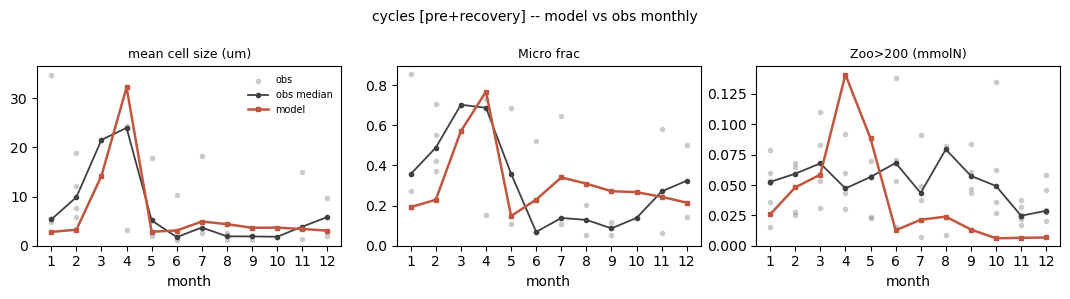

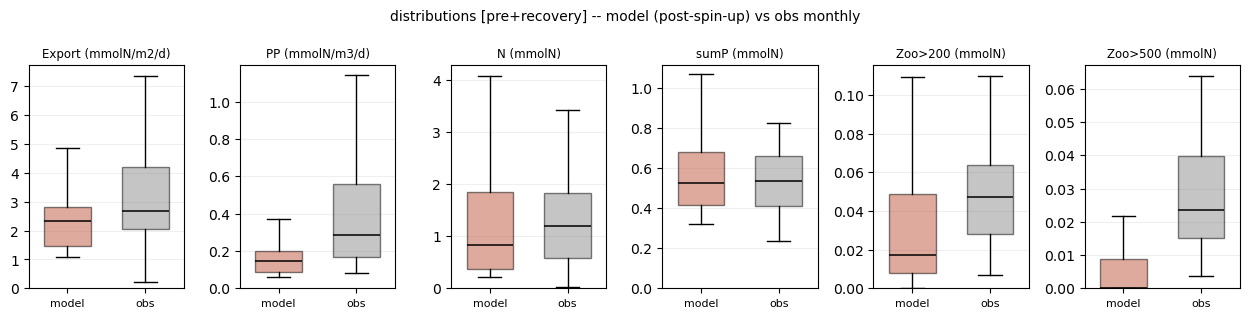

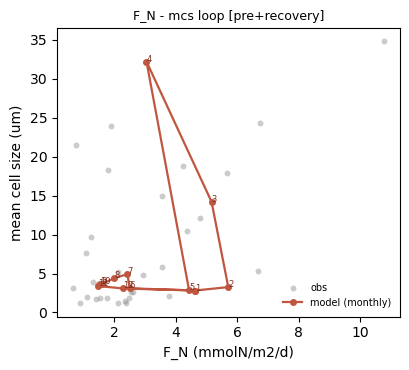


=== D amp-lens | {'GGE': 0.31, 'mP': 0.0015, 'm_Z': 0.1, 'KsZ': 0.23, 'sigma_log': 0.2} | fish=0.0 ===
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           3.14      4.88      2.46       2.3   -0.36   +0.07
pico         0.552     0.546     0.574     0.564   +0.01   +0.02
nano         0.249     0.258     0.246     0.264   -0.04   -0.07
micro        0.199     0.196     0.168     0.125   +0.02   +0.34
sumP         0.475     0.589     0.428      0.46   -0.19   -0.07
N            0.854      1.34     0.522      1.09   -0.37   -0.52
PP           0.119     0.323     0.102     0.202   -0.63   -0.50
Export        2.17      2.73      1.94      2.24   -0.20   -0.13
Z200        0.0557    0.0652    0.0365    0.0549   -0.14   -0.33
Z500        0.0174    0.0357   0.00369    0.0331   -0.51   -0.89
score   mean=0.179  med=0.177  joint(max)=0.179   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=0.99 Z200_peak=0.140 cv_

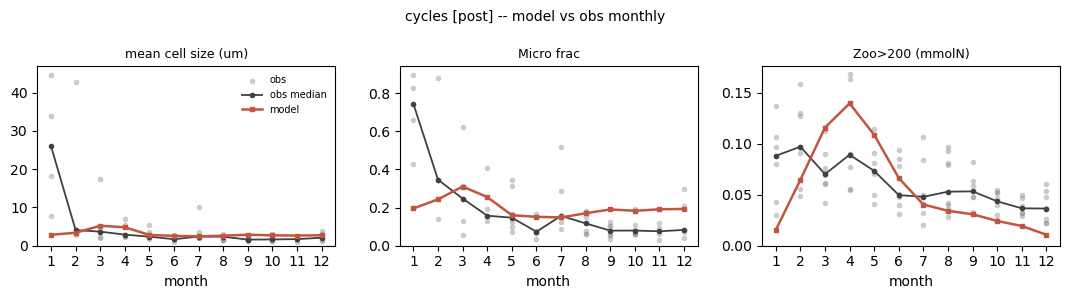

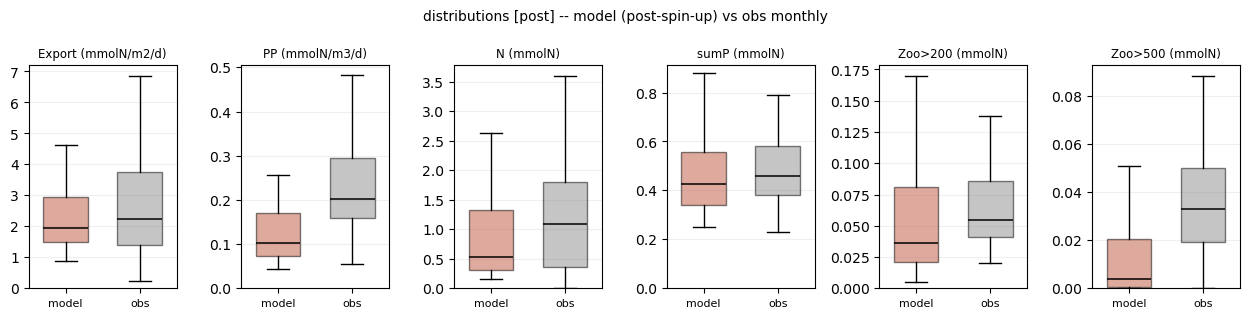

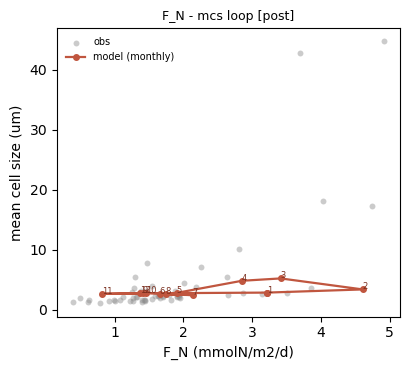

In [8]:
# --- Part 2: full visual diagnostic for ONE candidate (edit the index) ---
tag, P, pf = CANDS[3]          # 0=A, 1=B, 2=C, 3=D
for g, fish in (('pre+recovery', pf), ('post', 0.0)):
    clim, r = run_cand(P, g, fish)
    sd.diagnose(clim, r, group=g, spinup=15, obs_targets=obs_t, obs_monthly=obs_m,
                title=f"\n=== {tag} | {P} | fish={fish} ===")


{'construct': 'maranon_ward', 'GGE': 0.25, 'mP': 0.01, 'm_Z': 0.2, 'KsZ': 0.15, 'sigma_log': 0.25} | fish=0.2
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           5.18      8.65       4.5      4.84   -0.40   -0.07
pico         0.448     0.436     0.461     0.429   +0.03   +0.08
nano          0.21     0.217     0.209     0.205   -0.04   +0.02
micro        0.343     0.346     0.319     0.271   -0.01   +0.18
sumP         0.509     0.633     0.492     0.535   -0.19   -0.08
N             6.42      1.46      6.78       1.2   +3.41   +4.67
PP           0.179     0.548     0.182     0.286   -0.67   -0.36
Export        2.89      3.51      2.99      2.68   -0.18   +0.12
Z200        0.0633    0.0504    0.0635    0.0472   +0.26   +0.34
Z500        0.0177    0.0287     0.016    0.0235   -0.38   -0.32
score   mean=0.202  med=0.104  joint(max)=0.202   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=1.00 Z200

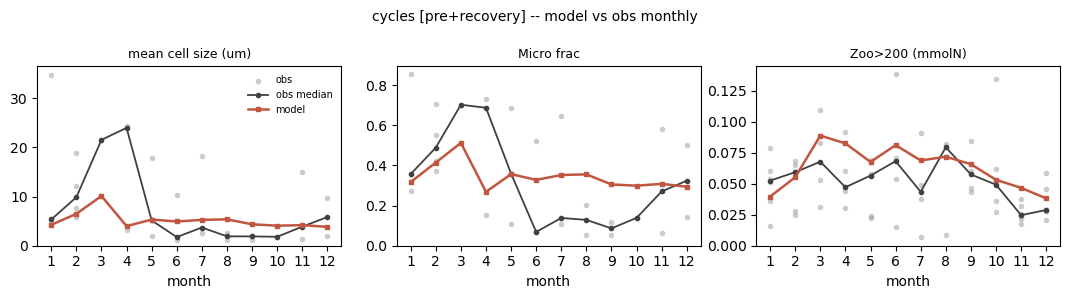

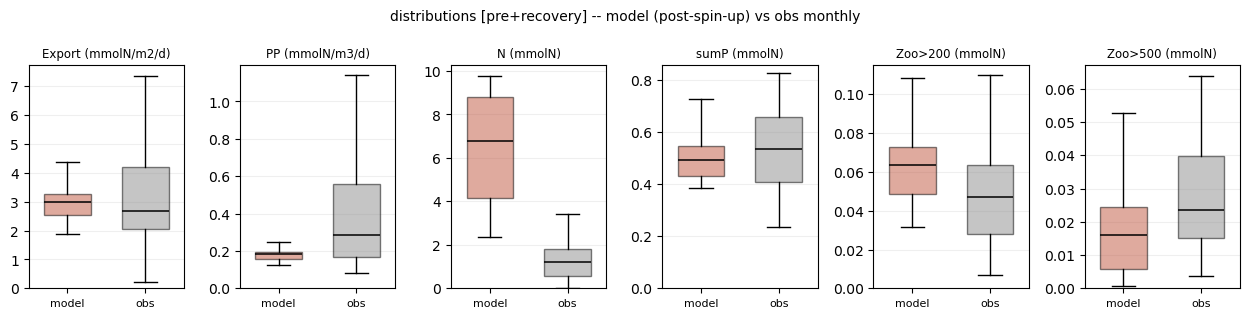

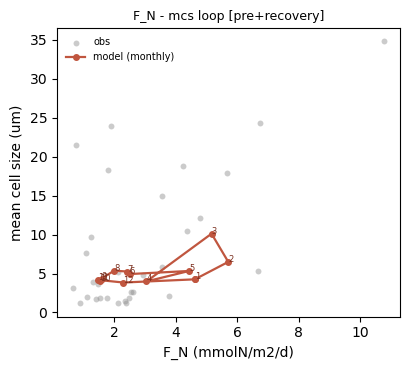


{'construct': 'maranon_ward', 'GGE': 0.25, 'mP': 0.01, 'm_Z': 0.2, 'KsZ': 0.15, 'sigma_log': 0.25} | fish=0.0
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           2.98      4.88      2.54       2.3   -0.39   +0.11
pico         0.553     0.546     0.568     0.564   +0.01   +0.01
nano         0.249     0.258     0.251     0.264   -0.04   -0.05
micro        0.198     0.196     0.174     0.125   +0.01   +0.39
sumP         0.356     0.589     0.345      0.46   -0.40   -0.25
N             2.51      1.34      2.52      1.09   +0.87   +1.31
PP           0.123     0.323     0.128     0.202   -0.62   -0.37
Export        2.27      2.73      2.42      2.24   -0.17   +0.08
Z200        0.0544    0.0652    0.0545    0.0549   -0.16   -0.01
Z500        0.0259    0.0357    0.0239    0.0331   -0.27   -0.28
score   mean=0.196  med=0.202  joint(max)=0.202   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=0.99 Z200_peak=0.

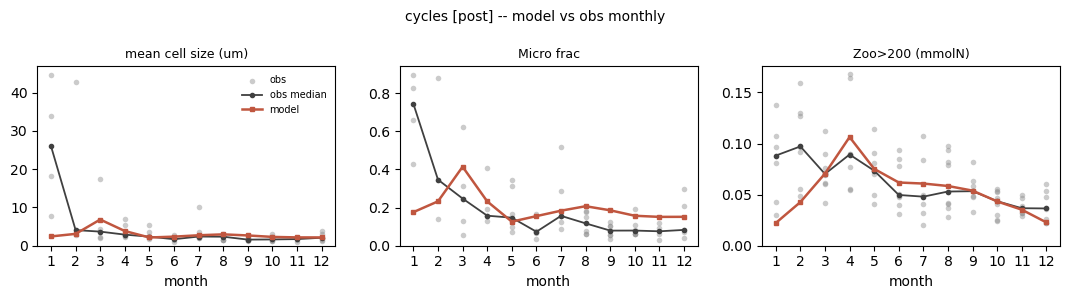

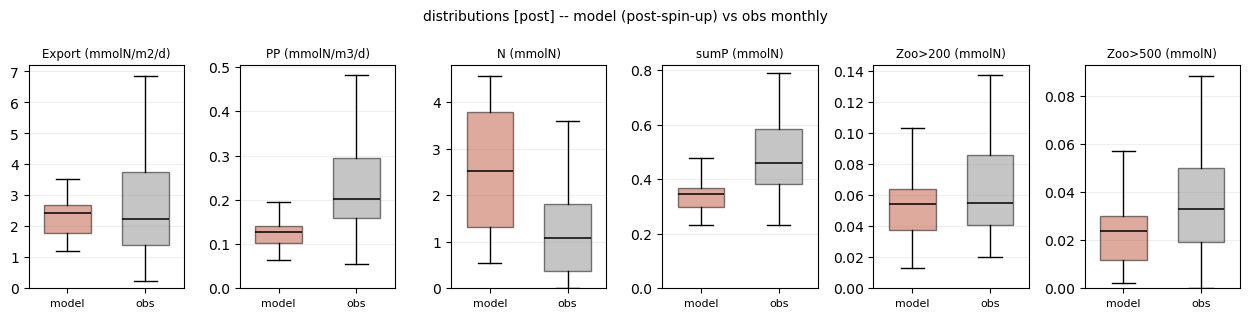

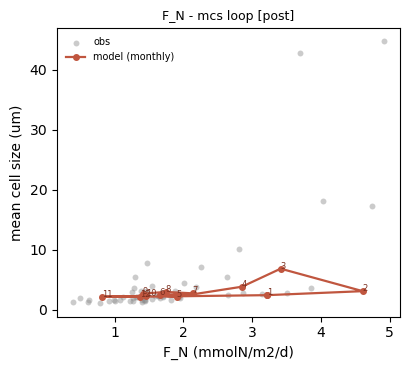

In [5]:
import seasonal_scan_harness as ssh, seasonal_diagnostics as sd

CAND = dict(construct='maranon_ward', GGE=0.25, mP=0.01, m_Z=0.20, KsZ=0.15, sigma_log=0.25)
FISH = {'pre+recovery': 0.2, 'post': 0.0}
SK   = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': -1e-2}

forc  = ssh.build_forcings(['pre+recovery', 'post'])
obs_t = ssh.build_obs_targets(['pre+recovery', 'post'])
obs_m = ssh.build_obs_monthly(['pre+recovery', 'post'])
spec  = ssh.allometry(CAND['construct'])
GRZ   = {'KsZ': CAND['KsZ'], 'sigma_log': CAND['sigma_log']}
IVO   = {'GrazingRouter': {'gge': CAND['GGE']}}

for g in ('pre+recovery', 'post'):
    clim, r = ssh.run_one(spec, forc[g], fish_rate=FISH[g], years=60, spinup=15,
                          mP=CAND['mP'], m_Z=CAND['m_Z'], grazing=GRZ,
                          iv_overrides=IVO, solver_kwargs=SK, return_traj=True)
    sd.diagnose(clim, r, group=g, spinup=15, obs_targets=obs_t, obs_monthly=obs_m,
                title=f"\n{CAND} | fish={FISH[g]}")

In [5]:
# reproducibility + reload-sensitivity of run_one for the candidate
import importlib, numpy as np
import seasonal_scan_harness as ssh

def trial(tag):
    spec = ssh.allometry('maranon_ward')
    F = ssh.build_forcings(['pre+recovery'])['pre+recovery']
    c = ssh.run_one(spec, F, fish_rate=0.3, years=60, spinup=15, m_Z=0.1,
                    grazing={'KsZ': 0.23, 'sigma_log': 0.2})
    print(f"{tag:22s} has_nan={c['has_nan']}  mcs={c.get('mcs', float('nan')):.3f}")

print("A) clean module, 3 back-to-back:")
for i in range(3): trial(f"  clean {i+1}")

print("B) after importlib.reload(ssh):")
importlib.reload(ssh)
for i in range(3): trial(f"  reloaded {i+1}")

A) clean module, 3 back-to-back:
  clean 1              has_nan=False  mcs=5.513
  clean 2              has_nan=False  mcs=5.513
  clean 3              has_nan=False  mcs=5.513
B) after importlib.reload(ssh):
  reloaded 1           has_nan=False  mcs=5.513
  reloaded 2           has_nan=False  mcs=5.513
  reloaded 3           has_nan=False  mcs=5.513



 maranon_ward | KsZ=0.23 sigma=0.2 m_Z=0.1 | fish=0.3
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           5.51      8.65      2.97      4.84   -0.36   -0.39
pico         0.496     0.436     0.535     0.429   +0.14   +0.25
nano         0.234     0.217     0.236     0.205   +0.08   +0.15
micro         0.27     0.346     0.213     0.271   -0.22   -0.21
sumP         0.747     0.633     0.562     0.535   +0.18   +0.05
N              1.3      1.46     0.868       1.2   -0.11   -0.27
PP            0.17     0.548     0.151     0.286   -0.69   -0.47
Export        2.67      3.51      2.52      2.68   -0.24   -0.06
Z200        0.0336    0.0504    0.0119    0.0472   -0.33   -0.75
Z500       0.00158    0.0287  5.44e-05    0.0235   -0.95   -1.00
score   mean=0.227  med=0.264  joint(max)=0.264   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=1.01 Z200_peak=0.128 cv_sumP=0.82
        mcs_peak month  model=4

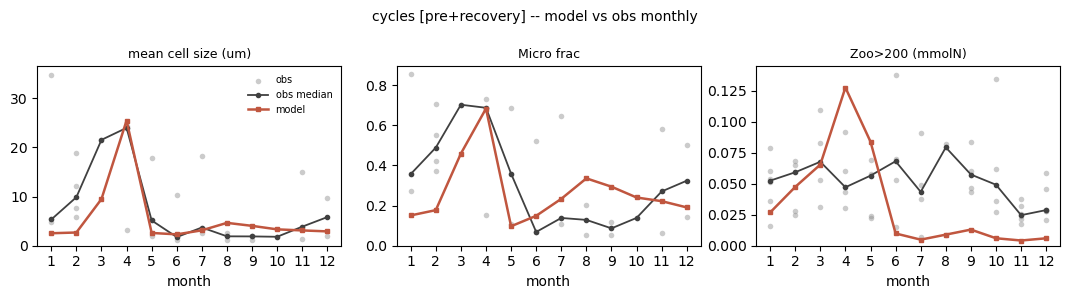

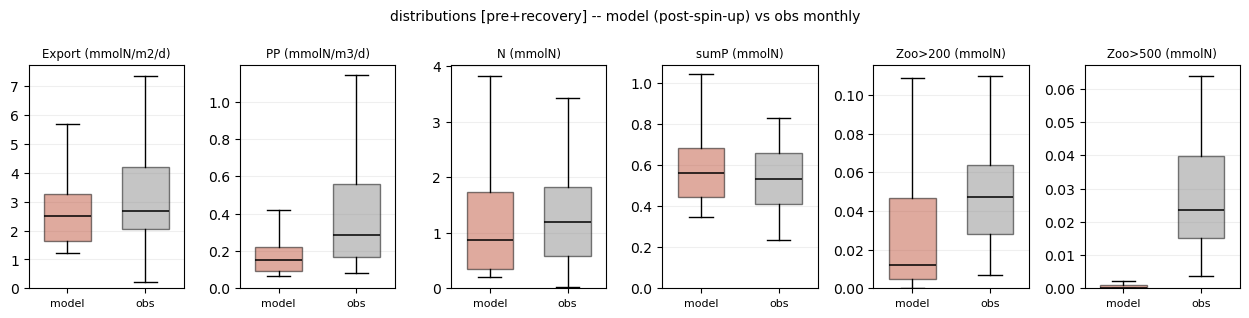

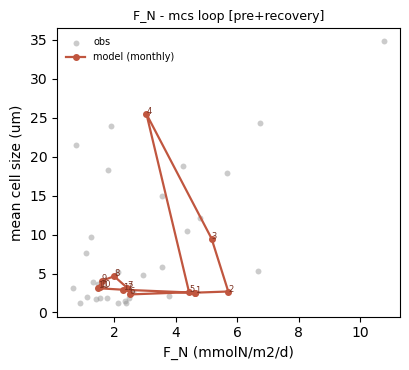


 maranon_ward | KsZ=0.23 sigma=0.2 m_Z=0.1 | fish=0.1
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           2.71      4.88      2.25       2.3   -0.44   -0.02
pico         0.574     0.546     0.591     0.564   +0.05   +0.05
nano         0.252     0.258     0.254     0.264   -0.02   -0.04
micro        0.173     0.196     0.146     0.125   -0.11   +0.16
sumP         0.473     0.589     0.409      0.46   -0.20   -0.11
N            0.712      1.34     0.422      1.09   -0.47   -0.61
PP           0.117     0.323    0.0978     0.202   -0.64   -0.52
Export        2.12      2.73      1.87      2.24   -0.22   -0.17
Z200        0.0198    0.0652   0.00574    0.0549   -0.70   -0.90
Z500       0.00232    0.0357  5.96e-05    0.0331   -0.93   -1.00
score   mean=0.231  med=0.088  joint(max)=0.231   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=0.99 Z200_peak=0.055 cv_sumP=0.33
        mcs_peak month  model=5  obs=1 

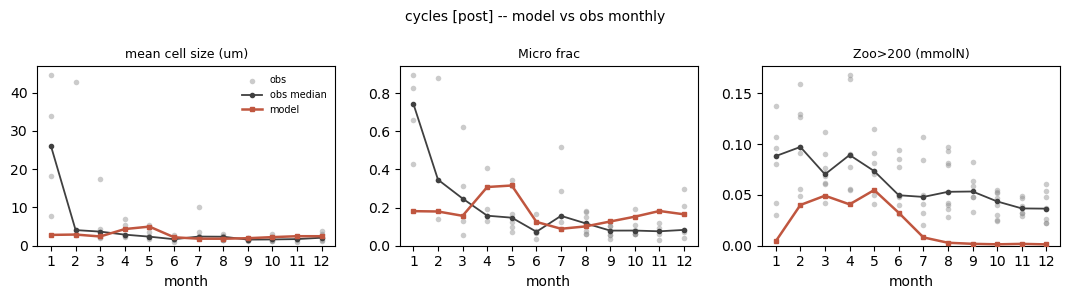

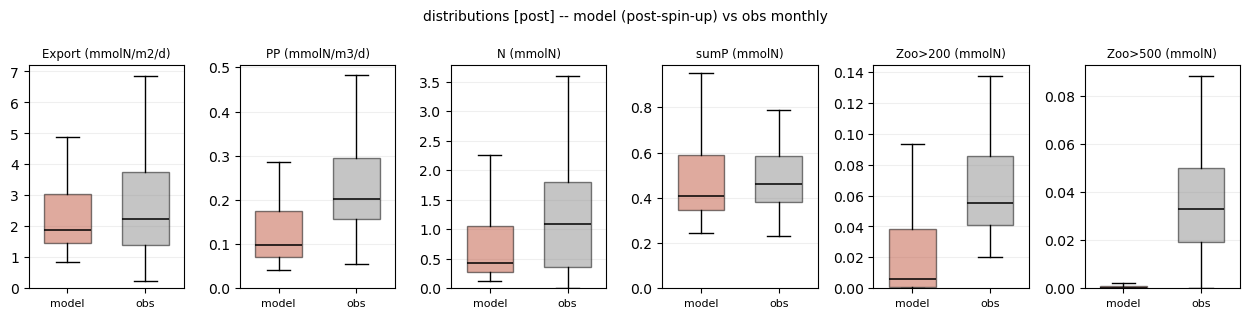

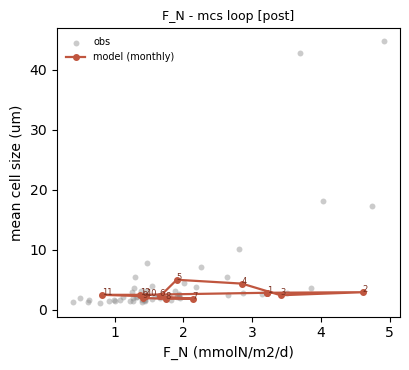

In [4]:
# --- seasonal diagnostic: candidate maranon_ward, graded fish, both eras ---
import importlib
import seasonal_scan_harness as ssh
import seasonal_diagnostics as sd
importlib.reload(ssh); importlib.reload(sd)

GROUPS = ('pre+recovery', 'post')
FISH   = {'pre+recovery': 0.3, 'post': 0.1}        # graded r_F (pre high / post low)
GRZ    = {'KsZ': 0.23, 'sigma_log': 0.2}           # candidate grazing
M_Z, YEARS, SPIN = 0.1, 60, 15

forc  = ssh.build_forcings(GROUPS)
obs_t = ssh.build_obs_targets(GROUPS)
obs_m = ssh.build_obs_monthly(GROUPS)
spec  = ssh.allometry('maranon_ward')

for g in GROUPS:
    clim, r = ssh.run_one(spec, forc[g], fish_rate=FISH[g], years=YEARS, spinup=SPIN,
                          m_Z=M_Z, grazing=GRZ, return_traj=True)
    sd.diagnose(clim, r, group=g, spinup=SPIN, obs_targets=obs_t, obs_monthly=obs_m,
                title=f"\n maranon_ward | KsZ={GRZ['KsZ']} sigma={GRZ['sigma_log']} "
                      f"m_Z={M_Z} | fish={FISH[g]}")